## Ground Truth Generation

In [1]:
# %pip install networkx graphviz numpy pgmpy torch matplotlib

In [2]:
import random
import graphviz
import networkx as nx
import numpy as np
import os, time
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

import torch
import torch.nn as nn
import pandas as pd

from tqdm import tqdm
import matplotlib.pyplot as plt
import psutil


/home/kaylin/CSprojects/Neural-Discrete-Bayesian-Network/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DAG Generation

In [3]:
#min in-degree?
def generate_dag(n, max_in_degree, max_density, seed):

    # Random topological order
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)

    # Create DAG
    G = nx.DiGraph()
    G.add_nodes_from(order)
    max_edges = round(max_density*n*(n-1)/2)

    # Feasibility Check
    ceiling = sum(min(i, max_in_degree) for i in range(n))
    if max_edges > ceiling:
        print(f"warning: density {max_density} needs {max_edges} edges, but max in-degree allows only {ceiling}")
        max_edges = ceiling
        max_density = max_edges / (n*(n-1)/2)

    # Backbone - Ensure weak connectivity
    for i in range(1, n):
        child = order[i]
        parent = rng.choice(order[:i])
        G.add_edge(parent, child)

    # Extra edges
    possible_edges = [(order[i], order[j]) for j in range(n) for i in range(j)]
    rng.shuffle(possible_edges)

    for u,v in possible_edges:
        if(G.has_edge(u,v)):
            continue
        if(G.number_of_edges() >= max_edges):
            break

        G.add_edge(u,v)
        if(G.number_of_edges() / (n*(n-1)/2) >= max_density):
            G.remove_edge(u,v)
            break

    return G
 

#### Test

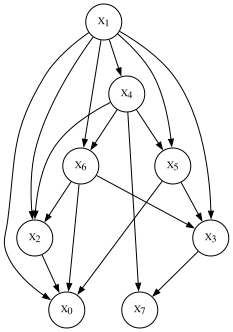

In [4]:
N_NODES = 8
CARDINALITY = 2
ALPHA = 1.0

MAX_IN_DEGREE = 3
MAX_DENSITY = 0.8

dag = generate_dag(
    n=N_NODES,
    max_in_degree=MAX_IN_DEGREE,
    max_density=MAX_DENSITY,
    seed=123
)

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in dag.edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot

### Ground Truth CPTs
Populate ground-truth CPTs from Dirichlet

In [5]:
def gen_CPTs(G, card, alpha, seed):

    rng = np.random.default_rng(seed)
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    cpds = []
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        n_configs = card ** len(parents)
        vals = rng.dirichlet([alpha] * card, size=n_configs).T   # (card, n_configs)
        cpd = TabularCPD(
            variable=node, variable_card=card, values=vals,
            evidence=parents or None,
            evidence_card=[card] * len(parents) or None,
            state_names={v: list(range(card)) for v in [node] + parents},
        )
        cpds.append(cpd)
 
    model.add_cpds(*cpds)
    model.check_model()
    return model


#### Test

In [6]:
ground_truth = gen_CPTs(G=dag, card=CARDINALITY, alpha=ALPHA, seed=456)

for cpd in ground_truth.get_cpds():
    print(f"{cpd} \n")

+--------+----------+
| X_1(0) | 0.538859 |
+--------+----------+
| X_1(1) | 0.461141 |
+--------+----------+ 

+--------+---------------------+----------------------+
| X_1    | X_1(0)              | X_1(1)               |
+--------+---------------------+----------------------+
| X_4(0) | 0.32406706937795593 | 0.981314983195667    |
+--------+---------------------+----------------------+
| X_4(1) | 0.6759329306220442  | 0.018685016804333033 |
+--------+---------------------+----------------------+ 

+--------+---------------------+-----+---------------------+
| X_1    | X_1(0)              | ... | X_1(1)              |
+--------+---------------------+-----+---------------------+
| X_4    | X_4(0)              | ... | X_4(1)              |
+--------+---------------------+-----+---------------------+
| X_5(0) | 0.06863164792155352 | ... | 0.5398787090259637  |
+--------+---------------------+-----+---------------------+
| X_5(1) | 0.9313683520784465  | ... | 0.46012129097403637 |
+-----

### Evaluation Functions

In [7]:


def logprob(model, data):
    return np.array([
        np.log(model.get_state_probability(dict(row)))
        for _, row in data.iterrows()
    ])

def logprob_fast(model, data):
    total = np.zeros(len(data))
    for cpd in model.get_cpds():
        node = cpd.variable
        parents = cpd.variables[1:]
        vals = cpd.get_values()
        row = data[node].to_numpy().astype(int)
        if parents:
            col = np.ravel_multi_index(data[parents].to_numpy().astype(int).T, cpd.cardinality[1:])
        else:
            col = 0
        total += np.log(np.clip(vals[row, col], 1e-12, 1.0))
    return total

def neural_logprob(nn_models, G, data, card):
    total = np.zeros(len(data))
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        X = one_hot(data, parents, card)
        y = data[node].to_numpy().astype(int)
        with torch.no_grad():
            probs = torch.softmax(nn_models[node](X), dim=1).numpy()
        total += np.log(np.clip(probs[np.arange(len(data)), y], 1e-12, 1))
    return total

#KL estimated on held-out test set

def kl_divergence(true_cpd, learned_cpd, test_data):
    # D(P* || P^) = E_{x~P*}[ log P*(x) - log P^(x) ]
    # estimated on held-out test set
    
    logp_true = logprob_fast(true_cpd, test_data)
    logp_learned = logprob_fast(learned_cpd, test_data)
   
    pointwise = logp_true - logp_learned
    return pointwise.mean(), pointwise.std() / np.sqrt(len(pointwise))

'''
def kl_divergence(true_model, learned_model):
    eps = 1e-12
    total = 0.0
    for node in true_model.nodes():
        true_cpd = true_model.get_cpds(node)
        learned_cpd = learned_model.get_cpds(node)
        if true_cpd.variables[1:]:
            learned_cpd.reorder_parents(true_cpd.variables[1:])

        P = np.clip(true_cpd.get_values(), eps, 1)   # (card, n_configs)
        Q = np.clip(learned_cpd.get_values(), eps, 1)
        kl_per_config = (P * np.log(P / Q)).sum(axis=0)  # KL per parent config

        total += kl_per_config.mean()  # uniform weight over configs

    return total
'''

def nn_cpd_values(nn_model, n_parents, card):
    """Get the NN's output distribution for every parent config — same shape as a CPT."""
    if n_parents == 0:
        configs = torch.zeros((1, 1))
    else:
        # all parent configs as one-hot: (card^n_parents, n_parents * card)
        indices = torch.arange(card ** n_parents)
        multi = []
        for _ in range(n_parents):
            multi.append(indices % card)
            indices = indices // card
        multi = torch.stack(multi[::-1], dim=1)
        configs = torch.nn.functional.one_hot(multi, card).reshape(-1, n_parents * card).float()

    with torch.no_grad():
        return torch.softmax(nn_model(configs), dim=1).numpy().T  # (card, n_configs)

def cpd_param_stats(cpd):
    """Exact size stats for one learned CPT.
 
    Returns dict with:
      in_degree     : number of parents
      stored_params : entries physically stored  = card * n_parent_configs
      free_params   : independent parameters     = (card-1) * n_parent_configs
      memory_bytes  : exact float64 buffer size  = get_values().nbytes
    """
    vals = cpd.get_values()                 # shape (card, n_parent_configs)
    card, n_configs = vals.shape
    in_degree = len(cpd.variables) - 1
    return {
        "in_degree":     in_degree,
        "stored_params": int(card * n_configs),
        "free_params":   int((card - 1) * n_configs),
        "memory_bytes":  int(vals.nbytes),
    }

def timed_fit(fit_fn, *args, **kwargs):
    """Run fit_fn(*args, **kwargs), returning (model, fit_time_s, rss_delta_bytes).
 
    rss_delta is only meaningful averaged over repeats and is noisy; the
    analytical/nbytes parameter curve is the precise memory evidence.
    """
    rss_before = None
    proc = psutil.Process(os.getpid())
    rss_before = proc.memory_info().rss
 
    t0 = time.perf_counter()
    model = fit_fn(*args, **kwargs)
    fit_time = time.perf_counter() - t0
 
    rss_delta = proc.memory_info().rss - rss_before
    return model, fit_time, rss_delta


### MLE


In [8]:
# MLE with normal default for unseen parent configurations
def fit_mle(G, data, card):
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    estimator = DiscreteMLE()
    # force full state space so unobserved states aren't dropped
    estimator.state_names = {v: list(range(card)) for v in G.nodes()}
    model.fit(data, estimator=estimator)
    return model

# MLE with a small symmetric Dirichlet pseudocount
def fit_mle_pseudocount(G, data, card):
    pseudo_count=0.5
    m = DiscreteBayesianNetwork(list(G.edges()))
    m.add_nodes_from(G.nodes())
    est = DiscreteBayesianEstimator(
        state_names={v: list(range(card)) for v in G.nodes()},
        prior_type="dirichlet",
        pseudo_counts=float(pseudo_count),   # 0.1–1.0 is a sensible range
    )
    m.fit(data, estimator=est)
    return m


#### Test


In [ ]:
N, CARD, ALPHA = 2000, 2, 1.0

G = generate_dag(n=8, max_in_degree=3, max_density=0.3, seed=123)
n = G.number_of_nodes()

print(f"Max in-degree = {3} \nMax density = {round(0.3,2)}")
print(f"\n\nActual density: {G.number_of_edges() / (n*(n-1)/2):.3f}")
print("In-degrees:", dict(sorted(G.in_degree(), key=lambda kv: kv[0])))

ground_truth = gen_CPTs(G=G, card=CARDINALITY, alpha=ALPHA, seed=456)

# sample
data = ground_truth.simulate(n_samples=N, seed=3, show_progress=False)
test_data = ground_truth.simulate(n_samples=N, seed=3, show_progress=False)
print(f"\nSampled {len(data)} rows")

# parameter estimation
mle_model = fit_mle(G, data, CARD)

kl_mle, se_mle = kl_divergence(ground_truth, mle_model, test_data)
print(f"KL = {kl_mle:>10.4f}")


Max in-degree = 3 
Max density = 0.3


Actual density: 0.286
In-degrees: {'X_0': 2, 'X_1': 0, 'X_2': 1, 'X_3': 1, 'X_4': 1, 'X_5': 1, 'X_6': 1, 'X_7': 1}

Sampled 2000 rows


TypeError: unsupported format string passed to tuple.__format__

## Neural Network CPDs

In [ ]:
# Linear Softmax Baseline
class NodeNN(nn.Module):
    # one-hot parent config -> softmax distribution over child states
    def __init__(self, n_parents, card, hidden_dims=()):
        super().__init__()
        in_dim = n_parents * card
        dims = [in_dim, *hidden_dims]
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers += [nn.Linear(dims[-1], card)]   # logits - softmax via the loss
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x) # raw logits
 
 
def one_hot(data, parents, card):
    if not parents:
        return torch.zeros((len(data), 1), dtype=torch.float32)
    idx = torch.tensor(data[parents].to_numpy().astype(np.int64), dtype=torch.long)
    one_hot = torch.nn.functional.one_hot(idx, num_classes=card)   # (rows, parents, card)
    return one_hot.reshape(len(idx), -1).float()
 
 
def train_node_nn(data, node, parents, card, hidden_dims=(32,),
                  epochs=200, lr=1e-3, weight_decay=1e-4, seed=0):
    # train one neural CPD for a node given its parents
    torch.manual_seed(seed)
    X = one_hot(data[parents].to_numpy(), card)
    y = torch.tensor(data[node].to_numpy().astype(np.int64), dtype=torch.long)
 
    model = NodeNN(len(parents), card, hidden_dims)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()        # softmax + NLL in one
 
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    return model

## Experiments

In [ ]:
# experiment configs

NODE_COUNTS  = [5, 10, 15, 20, 30, 40]
IN_DEGREES   = [2, 4, 6, 8, 10]          # max_in_degree
DENSITIES    = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
ALPHAS       = [0.1, 0.5, 1.0, 5.0] # sparse/peaked -> flat/uniform
SIM          = 5                   # random DAGs per config

CARD         = 2                   
ALPHA        = 1.0                 # Dirichlet concentration for ground-truth CPTs

SAMPLE_SIZES     = [600, 1000, 1400]
PLOT_SAMPLE_SIZE = 1000
MIN_OBS          = 3               # min DAGs per in-degree bin to plot a point

N_TEST           = 10000
RESULTS_DIR = "mle_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def is_feasible(n, k, density):
    """Can max_in_degree k support the target density on n nodes?"""
    max_possible_edges = n * (n - 1) / 2
    ceiling = sum(min(i, k) for i in range(n))
    return ceiling / max_possible_edges >= density


experiment_configs = [
    (n, k, d, a)
    for n in NODE_COUNTS
    for k in IN_DEGREES
    for d in DENSITIES
    for a in ALPHAS
    if is_feasible(n, k, d)
]

print(f"Feasible configs: {len(experiment_configs)} / {len(NODE_COUNTS)*len(IN_DEGREES)*len(DENSITIES)} total")

# experiment loop

plot_records = []   # (n_nodes, actual_density, in_degree, kl, sample_size)

for n_nodes, in_deg, max_density, alpha in tqdm(experiment_configs, desc="configs"):
    data_dir = os.path.join(RESULTS_DIR, "data")
    os.makedirs(data_dir, exist_ok=True)
    node_dir = os.path.join(data_dir, f"BN_{n_nodes}")
    os.makedirs(node_dir, exist_ok=True)
    in_deg_dir = os.path.join(node_dir, f"indegree_{in_deg}")
    os.makedirs(in_deg_dir, exist_ok=True)

    for dag in range(1, SIM + 1):
        seed = 1000 * dag + 10 * in_deg + n_nodes
        G = generate_dag(n_nodes, in_deg, max_density=max_density, seed=seed)
        true_model = gen_CPTs(G, CARD, alpha, seed=seed + 1)

        dag_dir = os.path.join(in_deg_dir, f"dag_{dag}")
        os.makedirs(dag_dir, exist_ok=True)

        # actual density of this realised graph
        max_possible = n_nodes * (n_nodes - 1) / 2
        actual_density = G.number_of_edges() / max_possible if max_possible > 0 else 0

        # Generate train & test data ONCE per DAG, outside the sample-size loop
        if not os.path.exists(os.path.join(dag_dir, "train.csv")):
            data = true_model.simulate(n_samples=max(SAMPLE_SIZES), seed=seed, show_progress=False)
            data.to_csv(os.path.join(dag_dir, "train.csv"), index=False)
        else:
            data = pd.read_csv(os.path.join(dag_dir, "train.csv"))

        if not os.path.exists(os.path.join(dag_dir, "test.csv")):
            test_data = true_model.simulate(n_samples=N_TEST, seed=seed+9999, show_progress=False)
            test_data.to_csv(os.path.join(dag_dir, "test.csv"), index=False)
        else:
            test_data = pd.read_csv(os.path.join(dag_dir, "test.csv"))
 
        test_data = true_model.simulate(
            n_samples=N_TEST, seed=seed + 9999, show_progress=False
        )
        

        for samples in SAMPLE_SIZES:

            sample = data.iloc[:samples]

            mle_model, fit_time, rss_delta = timed_fit(fit_mle, G, sample, CARD)
            kl, se = kl_divergence(true_model, mle_model)

            total_stored = sum(cpd_param_stats(mle_model.get_cpds(nd))["stored_params"]
                               for nd in true_model.nodes())
            total_bytes  = sum(cpd_param_stats(mle_model.get_cpds(nd))["memory_bytes"]
                               for nd in true_model.nodes())
            plot_records.append({
                "n_nodes":       n_nodes,
                "actual_density": actual_density,
                "max_in_degree": in_deg,
                "alpha":         alpha,
                "sample_size":   samples,
                "kl":            kl,
                "fit_time_s":    fit_time,
                "fit_rss_delta_bytes": rss_delta,
                "total_stored_params": total_stored,
                "total_memory_bytes":  total_bytes,
            })

    #print(f"done  n={n_nodes}  max_in_deg={in_deg}  density={max_density}")

results_df = pd.DataFrame(plot_records)
results_df.to_csv(os.path.join(RESULTS_DIR, "results.csv"), index=False)


Feasible configs: 684 / 210 total


configs: 100%|██████████| 684/684 [8:18:51<00:00, 43.76s/it]     


### Plotting functions

In [ ]:
"""
RQ1 plotting. One reusable grouped-curve function covers the five line plots;
two dedicated functions handle the memory plots (they need the analytical overlay).

Reusable:
  plot_grouped_curves(df, x, hue, y, ...) covers, from the SAME network-level df:
    (1)  KL vs in-degree,   one curve per sample_size
    (1b) KL vs in-degree,   one curve per n_nodes
    (3)  KL vs sample_size, one curve per in-degree
    (3b) KL vs n_nodes,     one curve per in-degree
    (5)  fit_time vs in-degree, one curve per n_nodes

Dedicated:
    (2)  plot_memory_vs_indegree  - measured .nbytes + analytical c^(k+1) overlay
    (4)  plot_cardinality_wall    - analytical memory vs in-degree for several cards
"""

import numpy as np
import matplotlib.pyplot as plt

# distinct, colour-blind-friendly cycle; extended as needed
_PALETTE = ["#2563eb", "#e11d48", "#16a34a", "#d97706",
            "#7c3aed", "#0891b2", "#be185d", "#4d7c0f"]


def _colors(n):
    if n <= len(_PALETTE):
        return _PALETTE[:n]
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


def plot_grouped_curves(
    df, x, hue, y="kl",
    logy=True, err=None, min_obs=1,
    xlabel=None, ylabel=None, title=None, hue_label=None,
    out_path=None, ax=None, figsize=(7, 5),
):
    """Mean y vs x, one curve per distinct value of `hue`. Plain lines by default.

    err : None (default, no error indication), 'std', or 'sem'. When set, spread
          is drawn as error BARS on the markers (no shaded areas).
    min_obs : drop (x, hue) points aggregated from fewer than this many rows.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    hue_vals = sorted(df[hue].dropna().unique())
    colors = _colors(len(hue_vals))

    for hv, c in zip(hue_vals, colors):
        s = df[df[hue] == hv]
        g = s.groupby(x)[y].agg(["mean", "std", "sem", "count"]).reset_index()
        g = g[g["count"] >= min_obs]
        if g.empty:
            continue
        label = f"{hue_label or hue} = {hv}"
        if err in ("std", "sem"):
            ax.errorbar(g[x], g["mean"], yerr=g[err].fillna(0.0), marker="o",
                        lw=2, color=c, label=label, capsize=3, zorder=3)
        else:
            ax.plot(g[x], g["mean"], marker="o", lw=2, color=c,
                    label=label, zorder=3)

    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel or x, fontsize=12)
    ax.set_ylabel(ylabel or y, fontsize=12)
    if title:
        ax.set_title(title, fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax


def plot_memory_vs_indegree(df_param, card=2, out_path=None,
                            ax=None, figsize=(7, 5)):
    """(2) Exact per-node CPT memory vs actual in-degree + analytical overlay.
    Size depends only on in-degree (given card), so dedupe over nodes."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    sub = df_param[df_param["card"] == card] if "card" in df_param else df_param
    sub = sub.drop_duplicates(subset=["in_degree"]).sort_values("in_degree")
    ks = sub["in_degree"].to_numpy()

    ax.scatter(sub["in_degree"], sub["memory_bytes"], s=45,
               color="#2563eb", zorder=3, label="measured (.nbytes)")
    kk = np.arange(int(ks.min()), int(ks.max()) + 1)
    analytic = [8 * card ** (k + 1) for k in kk]
    ax.plot(kk, analytic, "--", color="#e11d48", lw=2,
            label=r"analytical $c^{k+1}\cdot 8$B")

    ax.set_yscale("log")
    ax.set_xlabel("Parent in-degree $k$", fontsize=12)
    ax.set_ylabel("CPT memory (bytes, log)", fontsize=12)
    ax.set_title(f"Exact CPT memory is exponential in in-degree (card={card})",
                 fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax


def plot_cardinality_wall(cards=(2, 3, 4, 5), max_k=12,
                          wall_bytes=None, out_path=None,
                          ax=None, figsize=(7, 5)):
    """(4) Analytical CPT memory vs in-degree for several cardinalities.
    Optionally draw a horizontal 'infeasibility' line at wall_bytes
    (e.g. 8 * 1024**3 for 8 GB) to mark where storage becomes infeasible."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    ks = np.arange(0, max_k + 1)
    for c, col in zip(cards, _colors(len(cards))):
        ax.plot(ks, [8 * c ** (k + 1) for k in ks], marker="o", lw=2,
                color=col, label=f"card = {c}")

    if wall_bytes:
        ax.axhline(wall_bytes, color="black", ls=":", lw=1.5,
                   label=f"{wall_bytes/1024**3:.0f} GB wall")

    ax.set_yscale("log")
    ax.set_xlabel("Parent in-degree $k$", fontsize=12)
    ax.set_ylabel("CPT memory (bytes, log)", fontsize=12)
    ax.set_title("Storage cost by cardinality: reaching the memory wall",
                 fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Storage cost by cardinality: reaching the memory wall'}, xlabel='Parent in-degree $k$', ylabel='CPT memory (bytes, log)'>)

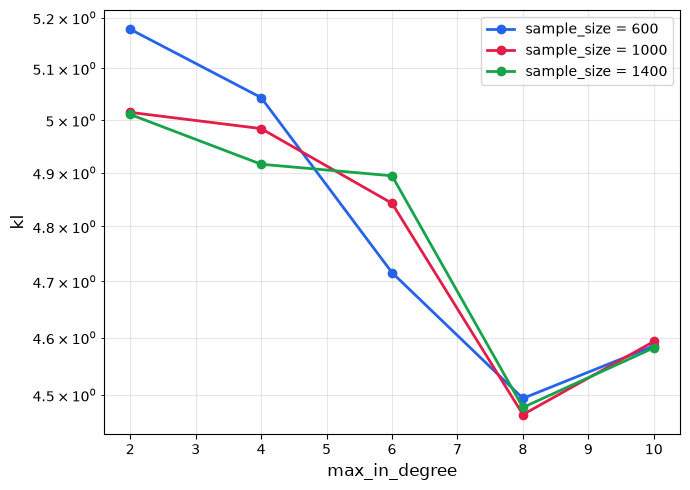

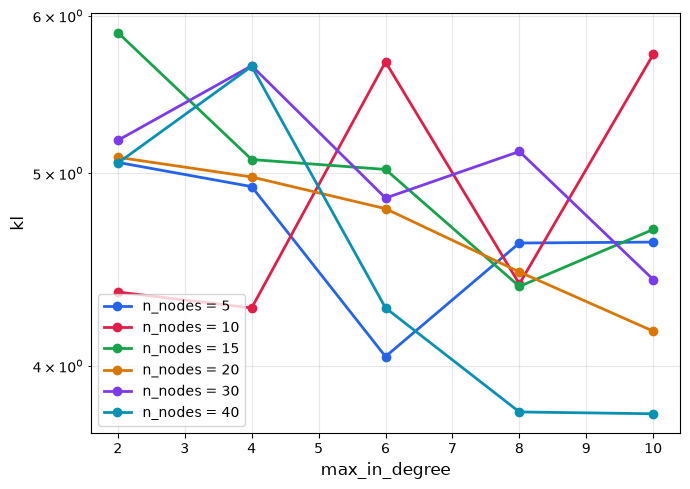

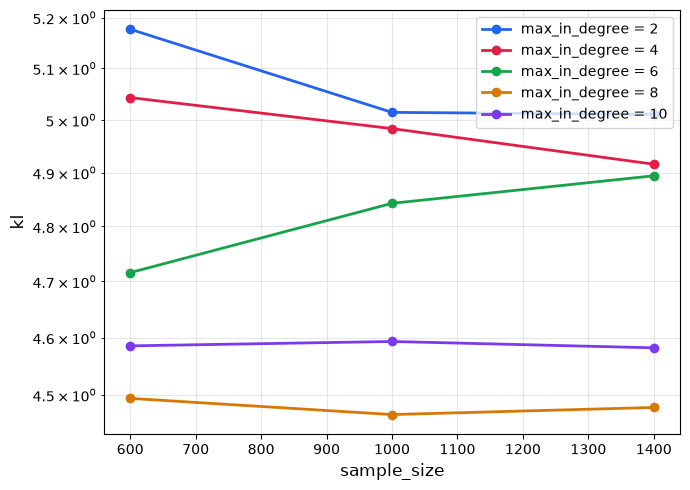

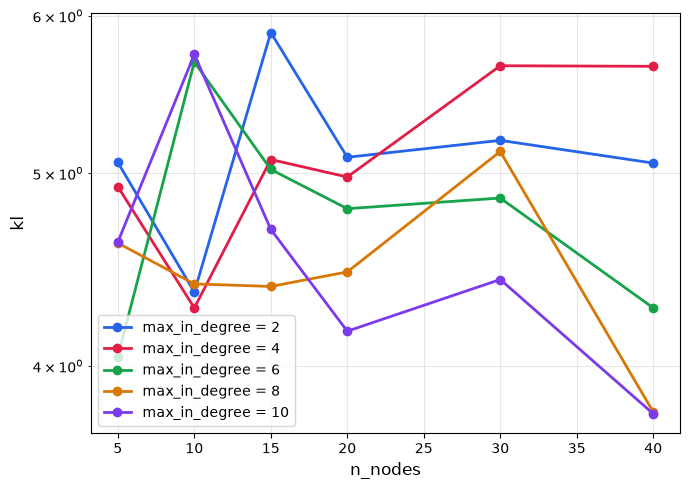

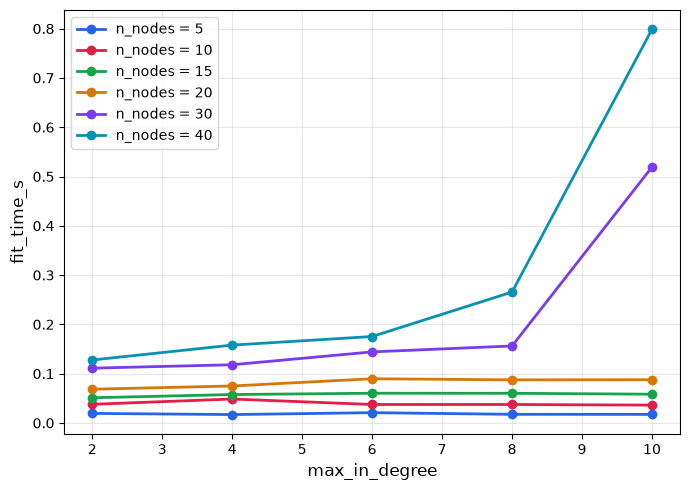

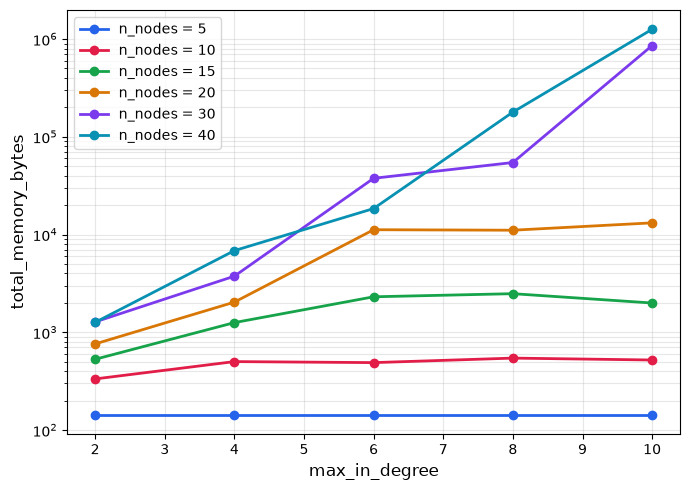

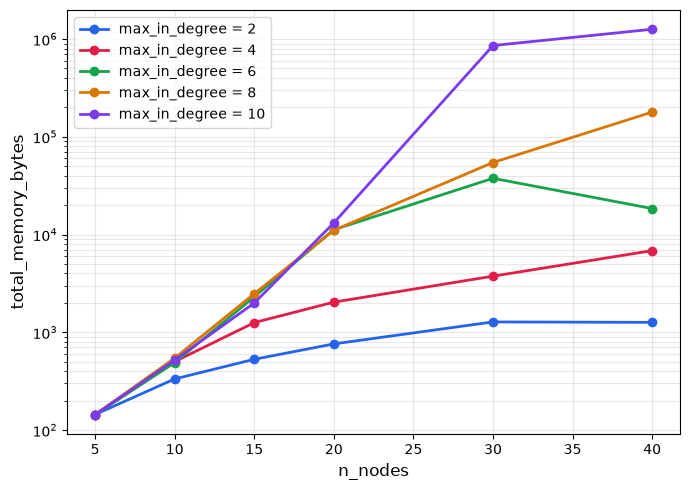

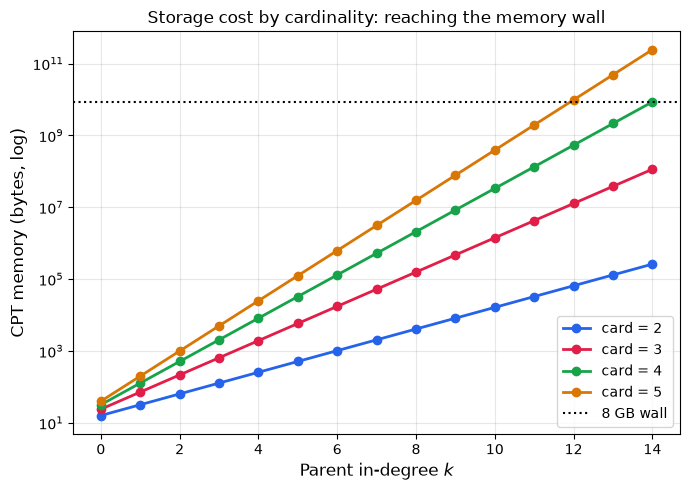

In [ ]:
df = pd.read_csv(f"{RESULTS_DIR}/results.csv")

plot_dir = os.path.join(RESULTS_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

# (1)  KL vs in-degree, one curve per sample size
plot_grouped_curves(df, x="max_in_degree", hue="sample_size", y="kl", out_path="kl_vs_indegree_by_samplesize.png")
# (1b) same, grouped by network size
plot_grouped_curves(df, x="max_in_degree", hue="n_nodes", y="kl", out_path="kl_vs_indegree_by_n_nodes.png")
# (3)  KL vs sample size, one curve per in-degree
plot_grouped_curves(df, x="sample_size", hue="max_in_degree", y="kl", out_path="kl_vs_samplesize.png")
# (3b) KL vs network size, one curve per in-degree
plot_grouped_curves(df, x="n_nodes", hue="max_in_degree", y="kl", out_path="kl_vs_networksize.png")
# (5)  training time — turn OFF log-y since it's seconds, not divergence
plot_grouped_curves(df, x="max_in_degree", hue="n_nodes", y="fit_time_s", logy=False, out_path="training_time.png")
# (2)  memory vs in-degree with analytical overlay
plot_grouped_curves(df, x="max_in_degree", hue="n_nodes", y="total_memory_bytes", out_path="memory_vs_indegree")
# (2)  memory vs in-degree with analytical overlay
plot_grouped_curves(df, x="n_nodes", hue="max_in_degree", y="total_memory_bytes", out_path="memory_vs_n_nodes")
# (4)  cardinality wall
plot_cardinality_wall(cards=(2,3,4,5), max_k=14, wall_bytes=8*1024**3, out_path="fig4.png")